# RavenStack — Customer Churn Prediction
## Notebook 05: Deployment & Prediction Pipeline

**Isi notebook ini:**
1. Load model yang sudah dilatih
2. Fungsi prediksi untuk pelanggan baru
3. Batch prediction (banyak pelanggan sekaligus)
4. Simulasi prediksi pelanggan baru
5. Risk scoring dashboard sederhana
6. Cara save & load model untuk production

---
## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_style('whitegrid')

print('✅ Library siap')

✅ Library siap


---
## 1. Load Model & Metadata

In [2]:
# Load model XGBoost yang sudah dilatih
model = joblib.load('../models/xgboost_optimized.pkl')

# Load metadata (threshold, params, metrics)
with open('../models/xgboost_metadata.json', 'r') as f:
    metadata = json.load(f)

THRESHOLD = metadata['threshold']

print('✅ Model berhasil di-load!')
print(f'Model     : {metadata["model"]}')
print(f'Threshold : {THRESHOLD}')
print()
print('Performa saat training:')
for k, v in metadata['metrics'].items():
    print(f'  {k:12}: {v}')
print()
print('Best params:')
for k, v in metadata['best_params'].items():
    print(f'  {k:20}: {v}')

✅ Model berhasil di-load!
Model     : XGBoost Optimized
Threshold : 0.32

Performa saat training:
  recall      : 0.6364
  precision   : 0.359
  f1          : 0.459
  auc_roc     : 0.6976

Best params:
  subsample           : 1.0
  reg_lambda          : 1.5
  reg_alpha           : 1.0
  n_estimators        : 1200
  min_child_weight    : 5
  max_depth           : 4
  learning_rate       : 0.005
  gamma               : 0.1
  colsample_bytree    : 0.8


---
## 2. Load Feature List

> Penting! Urutan dan nama kolom harus sama persis dengan saat training.

In [3]:
# Load dataset processed untuk ambil feature list
df_ref = pd.read_csv('../data/processed/ravenstack_features_for_modeling.csv')
bool_cols = df_ref.select_dtypes(include='bool').columns.tolist()
df_ref[bool_cols] = df_ref[bool_cols].astype(int)

FEATURE_COLS = [c for c in df_ref.columns if c != 'target']

print(f'Total fitur : {len(FEATURE_COLS)}')
print(f'Contoh fitur: {FEATURE_COLS[:10]}')

Total fitur : 83
Contoh fitur: ['seats', 'is_trial', 'tenure_days', 'total_subscriptions', 'active_subscriptions', 'churned_subscriptions', 'total_mrr', 'avg_mrr', 'max_mrr', 'total_arr']


---
## 3. Fungsi Prediksi

> Ini adalah **core function** yang akan dipakai di production.
> Cukup panggil `predict_churn()` dengan data pelanggan baru.

In [4]:
def predict_churn(data: pd.DataFrame,
                   model=model,
                   feature_cols=FEATURE_COLS,
                   threshold=THRESHOLD) -> pd.DataFrame:
    """
    Prediksi churn untuk satu atau banyak pelanggan.
    
    Parameters:
    -----------
    data         : DataFrame dengan kolom yang sama seperti training
    model        : model XGBoost yang sudah di-load
    feature_cols : list nama kolom fitur
    threshold    : batas probabilitas untuk klasifikasi churn
    
    Returns:
    --------
    DataFrame dengan kolom tambahan:
    - churn_probability : probabilitas churn (0-1)
    - churn_predicted   : 1 = churn, 0 = tidak
    - risk_category     : Low/Medium/High/Critical Risk
    - action            : rekomendasi tindakan
    """
    # Pastikan semua kolom ada
    X = data.reindex(columns=feature_cols, fill_value=0)
    
    # Konversi boolean
    bool_c = X.select_dtypes(include='bool').columns
    X[bool_c] = X[bool_c].astype(int)
    
    # Prediksi
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    
    # Risk category
    risk = pd.cut(
        proba,
        bins=[0, 0.25, 0.35, 0.45, 1.0],
        labels=['🟢 Low Risk', '🟡 Medium Risk', '🟠 High Risk', '🔴 Critical Risk']
    )
    
    # Rekomendasi tindakan
    action_map = {
        '🟢 Low Risk'     : 'Monitor rutin',
        '🟡 Medium Risk'  : 'Kirim email engagement',
        '🟠 High Risk'    : 'Hubungi CS + tawarkan diskon',
        '🔴 Critical Risk': 'Eskalasi ke account manager SEGERA',
    }
    
    result = data.copy()
    result['churn_probability'] = proba.round(4)
    result['churn_predicted']   = pred
    result['risk_category']     = risk.astype(str)
    result['action']            = result['risk_category'].map(action_map)
    
    return result.sort_values('churn_probability', ascending=False)

print('✅ Fungsi predict_churn() siap digunakan')

✅ Fungsi predict_churn() siap digunakan


---
## 4. Batch Prediction — Seluruh Dataset

In [5]:
# Prediksi semua pelanggan yang ada
X_all = df_ref[FEATURE_COLS].copy()

result_all = predict_churn(X_all)

print('=== Hasil Batch Prediction ===')
print(f'Total pelanggan   : {len(result_all)}')
print(f'Diprediksi churn  : {result_all["churn_predicted"].sum()}')
print(f'Tidak churn       : {(result_all["churn_predicted"]==0).sum()}')
print()
print('Distribusi Risk Category:')
print(result_all['risk_category'].value_counts().sort_index())

# Tampilkan top 10 paling berisiko
display_cols = ['churn_probability','churn_predicted','risk_category',
                'action','total_mrr','tenure_days','avg_satisfaction_score']
display_cols = [c for c in display_cols if c in result_all.columns]

print()
print('🚨 Top 10 Pelanggan Paling Berisiko:')
result_all[display_cols].head(10)

=== Hasil Batch Prediction ===
Total pelanggan   : 500
Diprediksi churn  : 171
Tidak churn       : 329

Distribusi Risk Category:
🔴 Critical Risk    108
🟠 High Risk         45
🟡 Medium Risk       80
🟢 Low Risk         267
Name: risk_category, dtype: int64

🚨 Top 10 Pelanggan Paling Berisiko:


,churn_probability,churn_predicted,risk_category,action,total_mrr,tenure_days,avg_satisfaction_score
54,0.8661,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,4498,729,3.5
25,0.8524,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,10162,666,4.5
126,0.8448,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,18249,73,3.8
122,0.8275,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,37312,506,3.0
84,0.8255,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,19604,692,0.0
428,0.7990,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,5624,528,4.5
292,0.7840,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,16984,54,3.0
394,0.7661,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,17315,415,4.5
395,0.7614,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,29884,311,4.0
27,0.7238,1,🔴 Critical Risk,Eskalasi ke account manager SEGERA,32433,614,5.0


Define X dan y 

In [6]:
# Define X dan y dari dataset
df_ref = pd.read_csv('../data/processed/ravenstack_features_for_modeling.csv')
bool_cols = df_ref.select_dtypes(include='bool').columns.tolist()
df_ref[bool_cols] = df_ref[bool_cols].astype(int)

X = df_ref[FEATURE_COLS]
y = df_ref['target']

---
## 5. Simulasi Prediksi Pelanggan Baru

> Simulasi ketika ada **pelanggan baru masuk** dan ingin langsung diprediksi.

In [7]:
# Load probabilitas dulu untuk pilih sampel yang tepat
X_all = df_ref[FEATURE_COLS].copy()
all_proba = model.predict_proba(X_all)[:, 1]

# Pelanggan A: churn + probabilitas tertinggi
idx_berisiko = (pd.Series(all_proba)[y==1]).idxmax()
profil_berisiko = X.iloc[[idx_berisiko]].copy()

# Pelanggan B: tidak churn + probabilitas TERENDAH (paling aman)
idx_sehat = (pd.Series(all_proba)[y==0]).idxmin()
profil_sehat = X.iloc[[idx_sehat]].copy()

# Pelanggan C: probabilitas paling mendekati threshold (borderline)
idx_borderline = (pd.Series(all_proba) - 0.32).abs().idxmin()
profil_borderline = X.iloc[[idx_borderline]].copy()

pelanggan_baru = pd.concat([
    profil_berisiko,
    profil_sehat,
    profil_borderline
], ignore_index=True)

hasil = predict_churn(pelanggan_baru)

print('=== Simulasi 3 Profil Pelanggan ===')
print()
nama = ['Pelanggan A (Churn - probabilitas tertinggi)',
        'Pelanggan B (Sehat - probabilitas terendah)',
        'Pelanggan C (Borderline - mendekati threshold 0.32)']

for i, (_, row) in enumerate(hasil.iterrows()):
    print('='*52)
    print(f'  {nama[i]}')
    print(f'  Probabilitas Churn : {row["churn_probability"]:.2%}')
    print(f'  Prediksi           : {"⚠️ CHURN" if row["churn_predicted"]==1 else "✅ AMAN"}')
    print(f'  Risk Category      : {row["risk_category"]}')
    print(f'  Rekomendasi Aksi   : {row["action"]}')

=== Simulasi 3 Profil Pelanggan ===

  Pelanggan A (Churn - probabilitas tertinggi)
  Probabilitas Churn : 86.61%
  Prediksi           : ⚠️ CHURN
  Risk Category      : 🔴 Critical Risk
  Rekomendasi Aksi   : Eskalasi ke account manager SEGERA
  Pelanggan B (Sehat - probabilitas terendah)
  Probabilitas Churn : 31.99%
  Prediksi           : ✅ AMAN
  Risk Category      : 🟡 Medium Risk
  Rekomendasi Aksi   : Kirim email engagement
  Pelanggan C (Borderline - mendekati threshold 0.32)
  Probabilitas Churn : 3.06%
  Prediksi           : ✅ AMAN
  Risk Category      : 🟢 Low Risk
  Rekomendasi Aksi   : Monitor rutin


---
## 6. Risk Dashboard Visualisasi

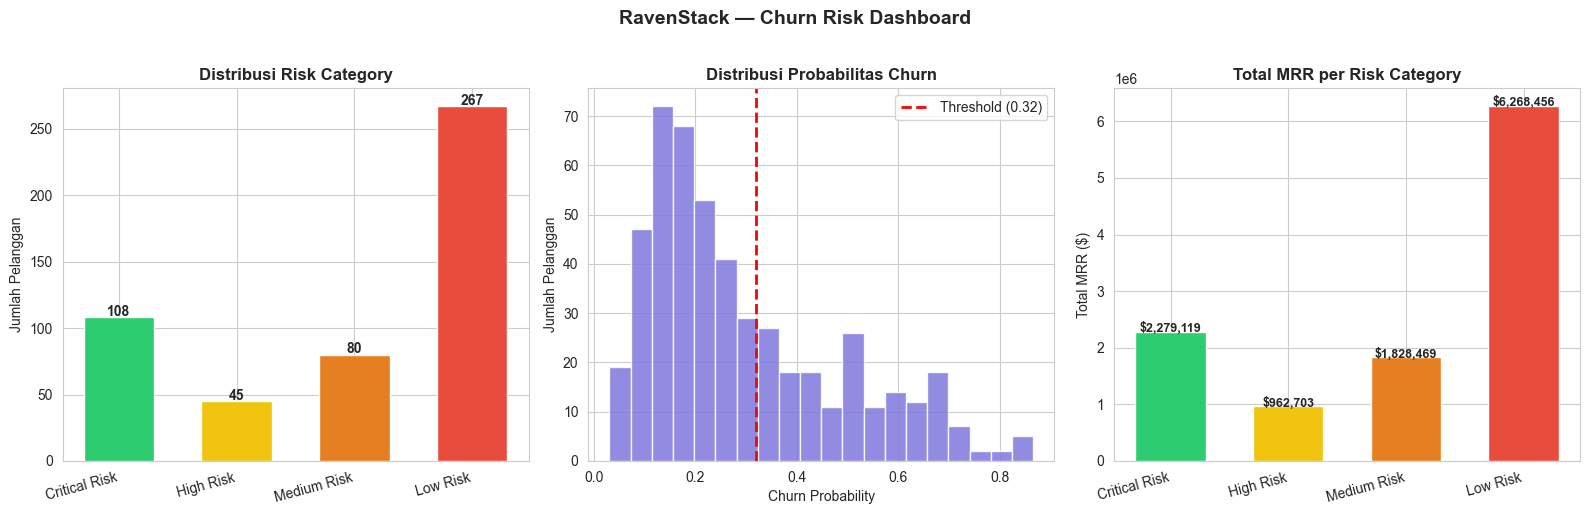

💾 Tersimpan: reports/09_risk_dashboard.png


In [8]:
import os
os.makedirs('../reports', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Distribusi Risk Category
risk_counts = result_all['risk_category'].value_counts().sort_index()
colors_risk = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
axes[0].bar(range(len(risk_counts)), risk_counts.values,
             color=colors_risk, edgecolor='white', width=0.6)
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels([r.split(' ', 1)[1] for r in risk_counts.index],
                          rotation=15, ha='right')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Risk Category', fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')

# Plot 2: Distribusi Probabilitas Churn
axes[1].hist(result_all['churn_probability'], bins=20,
              color='#7F77DD', edgecolor='white', alpha=0.85)
axes[1].axvline(x=THRESHOLD, color='red', linestyle='--',
                 linewidth=2, label=f'Threshold ({THRESHOLD})')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].set_title('Distribusi Probabilitas Churn', fontweight='bold')
axes[1].legend()

# Plot 3: MRR at Risk
if 'total_mrr' in result_all.columns:
    mrr_risk = result_all.groupby('risk_category')['total_mrr'].sum().sort_index()
    axes[2].bar(range(len(mrr_risk)), mrr_risk.values,
                 color=colors_risk, edgecolor='white', width=0.6)
    axes[2].set_xticks(range(len(mrr_risk)))
    axes[2].set_xticklabels([r.split(' ', 1)[1] for r in mrr_risk.index],
                              rotation=15, ha='right')
    axes[2].set_title('Total MRR per Risk Category', fontweight='bold')
    axes[2].set_ylabel('Total MRR ($)')
    for i, v in enumerate(mrr_risk.values):
        axes[2].text(i, v+10, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('RavenStack — Churn Risk Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/09_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/09_risk_dashboard.png')

---
## 7. Export Hasil & Cara Pakai di Production

In [9]:
# Simpan hasil prediksi lengkap
output_cols = ['churn_probability','churn_predicted','risk_category','action']
if 'total_mrr' in result_all.columns:
    output_cols += ['total_mrr','tenure_days','avg_satisfaction_score']

result_all[output_cols].to_csv(
    '../data/processed/ravenstack_final_predictions.csv', index=False
)
print('💾 Tersimpan: data/processed/ravenstack_final_predictions.csv')
print()

# Ringkasan untuk tim CS
critical = result_all[result_all['risk_category'].str.contains('Critical')]
high     = result_all[result_all['risk_category'].str.contains('High')]

print('=' * 55)
print('  RINGKASAN UNTUK TIM CUSTOMER SUCCESS')
print('=' * 55)
print(f'🔴 Critical Risk : {len(critical)} pelanggan → ESKALASI SEGERA')
print(f'🟠 High Risk     : {len(high)} pelanggan → Hubungi + tawarkan diskon')
if 'total_mrr' in result_all.columns:
    mrr_at_risk = result_all[result_all['churn_predicted']==1]['total_mrr'].sum()
    print(f'💰 Total MRR at risk : ${mrr_at_risk:,.2f}')
print()
print('=' * 55)
print('  CARA PAKAI MODEL DI PRODUCTION')
print('=' * 55)
print('''
1. Load model:
   model = joblib.load('models/xgboost_optimized.pkl')

2. Siapkan data pelanggan baru (harus punya kolom yang sama)

3. Prediksi:
   hasil = predict_churn(data_baru)

4. Ubah threshold sesuai kebutuhan bisnis:
   - Threshold rendah (0.25) → lebih agresif, Recall tinggi
   - Threshold tinggi (0.45) → lebih selektif, Precision tinggi

5. Kirim hasilnya ke tim CS untuk tindak lanjut
''')

💾 Tersimpan: data/processed/ravenstack_final_predictions.csv

  RINGKASAN UNTUK TIM CUSTOMER SUCCESS
🔴 Critical Risk : 108 pelanggan → ESKALASI SEGERA
🟠 High Risk     : 45 pelanggan → Hubungi + tawarkan diskon
💰 Total MRR at risk : $3,628,877.00

  CARA PAKAI MODEL DI PRODUCTION

1. Load model:
   model = joblib.load('models/xgboost_optimized.pkl')

2. Siapkan data pelanggan baru (harus punya kolom yang sama)

3. Prediksi:
   hasil = predict_churn(data_baru)

4. Ubah threshold sesuai kebutuhan bisnis:
   - Threshold rendah (0.25) → lebih agresif, Recall tinggi
   - Threshold tinggi (0.45) → lebih selektif, Precision tinggi

5. Kirim hasilnya ke tim CS untuk tindak lanjut

